In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# تحديد عدد السجلات
num_records = 1000

# 1. إنشاء أرقام الطلبات والتطوير
request_ids = [f"REQ-{1000 + i}" for i in range(num_records)]

# 2. توليد تواريخ عشوائية خلال النصف الأول من عام 2026
start_date = datetime(2026, 1, 1)
dates = [start_date + timedelta(days=int(np.random.randint(0, 150))) for _ in range(num_records)]

# 3. أنواع العمليات ومستويات الحساسية
categories = ['Join Request', 'Data Update', 'Role Permission', 'System Audit']
category_list = np.random.choice(categories, num_records, p=[0.4, 0.3, 0.2, 0.1])

sensitivity_levels = ['Low', 'Medium', 'High']
sensitivity_list = np.random.choice(sensitivity_levels, num_records, p=[0.5, 0.3, 0.2])

# 4. حالة العقد ومستوى الازدحام
contract_statuses = ['Active', 'Expired']
contract_list = np.random.choice(contract_statuses, num_records, p=[0.85, 0.15])

crowd_levels = ['Low', 'Medium', 'High']
crowd_list = np.random.choice(crowd_levels, num_records, p=[0.3, 0.5, 0.2])

# 5. حساب وقت المعالجة بناءً على مدخلات منطقية (حتى تكون البيانات واقعية)
processing_times = []
for i in range(num_records):
    base_time = 15
    if sensitivity_list[i] == 'High': base_time += 20
    if crowd_list[i] == 'High': base_time += 15
    # إضافة طابع عشوائي بسيط
    final_time = base_time + np.random.randint(-5, 10)
    processing_times.append(max(5, final_time))

# 6. تحديد مستوى الخطورة (المستهدف للتنبؤ المستقبلي) بناءً على شروط منطقية
risk_levels = []
for i in range(num_records):
    # إذا كان العقد منتهي والحساسية عالية -> خطورة مؤكدة
    if contract_list[i] == 'Expired' and sensitivity_list[i] in ['High', 'Medium']:
        risk_levels.append(1)
    # إذا كان الازدحام عالٍ والعملية تعديل صلاحيات
    elif crowd_list[i] == 'High' and category_list[i] == 'Role Permission':
        risk_levels.append(1)
    else:
        # نسبة خطورة عشوائية صغيرة للحالات العادية
        risk_levels.append(np.random.choice([0, 1], p=[0.92, 0.08]))

# جمع البيانات في DataFrame
df = pd.DataFrame({
    'Request_ID': request_ids,
    'Date': dates,
    'Category': category_list,
    'Sensitivity_Level': sensitivity_list,
    'Contract_Status': contract_list,
    'Crowd_Density_Level': crowd_list,
    'Processing_Time_Minutes': processing_times,
    'Risk_Level': risk_levels
})

# حفظ البيانات في ملف CSV
df.to_csv('operations_data.csv', index=False)
print("تم توليد ملف البيانات 'operations_data.csv' بنجاح يحتوي على 1000 سجل!")


تم توليد ملف البيانات 'operations_data.csv' بنجاح يحتوي على 1000 سجل!


--- أول 5 أسطر من البيانات ---
  Request_ID        Date         Category Sensitivity_Level Contract_Status  \
0   REQ-1000  2026-01-15  Role Permission            Medium          Active   
1   REQ-1001  2026-01-14     Join Request              High          Active   
2   REQ-1002  2026-04-07      Data Update               Low          Active   
3   REQ-1003  2026-02-10      Data Update               Low          Active   
4   REQ-1004  2026-05-18      Data Update              High          Active   

  Crowd_Density_Level  Processing_Time_Minutes  Risk_Level  
0              Medium                       22           0  
1                 Low                       41           0  
2                 Low                       10           0  
3                 Low                       11           0  
4              Medium                       44           0  


--- معلومات عامة عن البيانات ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 

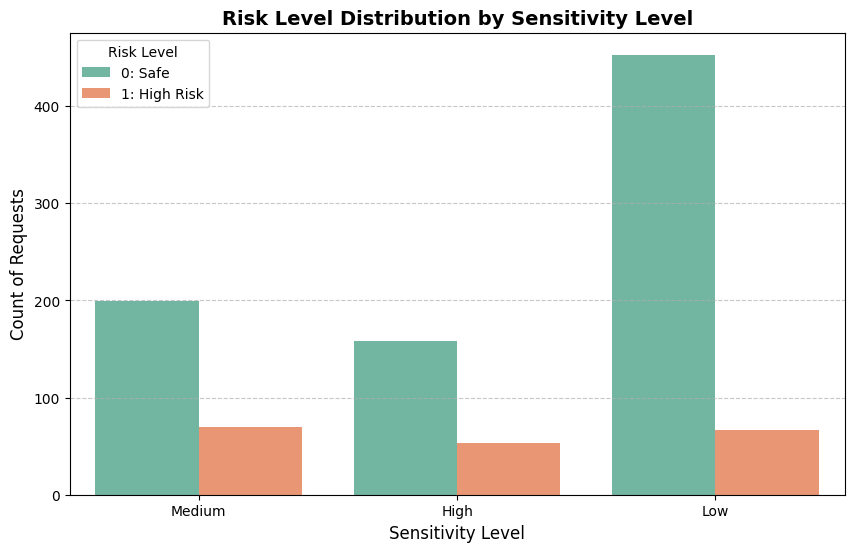

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. قراءة ملف البيانات الذي قمنا بتوليده
df = pd.read_csv('operations_data.csv')

# 2. عرض أول 5 أسطر من البيانات للتأكد من سلامتها
print("--- أول 5 أسطر من البيانات ---")
print(df.head())
print("\n" + "="*50 + "\n")

# 3. عرض معلومات عامة عن الأعمدة وأنواع البيانات
print("--- معلومات عامة عن البيانات ---")
print(df.info())
print("\n" + "="*50 + "\n")

# 4. إظهار توزيع حالات الخطورة (Risk_Level) كم عدد الحالات الآمنة والخطيرة؟
print("--- توزيع مستويات الخطورة (0 = آمن, 1 = خطير) ---")
print(df['Risk_Level'].value_counts())
print("\n" + "="*50 + "\n")

# 5. الرسم البياني: يوضح العلاقة بين مستوى الحساسية ومستوى الخطورة
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sensitivity_Level', hue='Risk_Level', palette='Set2')

# تحسين مظهر الرسم البياني
plt.title('Risk Level Distribution by Sensitivity Level', fontsize=14, fontweight='bold')
plt.xlabel('Sensitivity Level', fontsize=12)
plt.ylabel('Count of Requests', fontsize=12)
plt.legend(title='Risk Level', labels=['0: Safe', '1: High Risk'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# عرض الرسم البياني داخل كولاب
plt.show()


--- دقة النموذج الإجمالية (Model Accuracy): 93.00% ---

--- تقرير التصنيف المفصل (Classification Report) ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       176
           1       0.73      0.67      0.70        24

    accuracy                           0.93       200
   macro avg       0.84      0.82      0.83       200
weighted avg       0.93      0.93      0.93       200



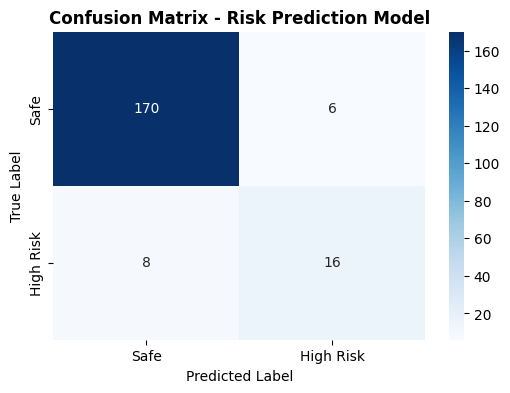

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. قراءة البيانات
df = pd.read_csv('operations_data.csv')

# 2. تحويل الأعمدة النصية إلى أرقام (One-Hot Encoding) ليفهمها النموذج
# سنقوم بتحويل أعمدة الـ Category, Sensitivity_Level, Contract_Status, Crowd_Density_Level
df_encoded = pd.get_dummies(df, columns=['Category', 'Sensitivity_Level', 'Contract_Status', 'Crowd_Density_Level'], drop_first=True)

# 3. تحديد المدخلات (X) والمستهدف المراد التنبؤ به (y)
X = df_encoded.drop(columns=['Request_ID', 'Date', 'Risk_Level'])
y = df_encoded['Risk_Level']

# 4. تقسيم البيانات: 80% للتدريب (Training) و 20% للاختبار (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. بناء وتدريب نموذج Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. جعل النموذج يتنبأ على بيانات الاختبار
y_pred = model.predict(X_test)

# 7. طباعة تقييم أداء النموذج (Accuracy & Classification Report)
print(f"--- دقة النموذج الإجمالية (Model Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}% ---")
print("\n--- تقرير التصنيف المفصل (Classification Report) ---")
print(classification_report(y_test, y_pred))

# 8. رسم الـ Confusion Matrix لإظهار دقة التنبؤ بالـ Safe والـ High Risk بصرياً
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'High Risk'], yticklabels=['Safe', 'High Risk'])
plt.title('Confusion Matrix - Risk Prediction Model', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:

with open('app.py', 'w') as f:
    f.write('''
import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. إعداد عنوان الصفحة والمظهر
st.set_page_config(page_title="Smart Operations & Risk Predictor", layout="centered")
st.title("🛡️ Smart Operations & Risk Prediction System")
st.write("هذا النظام الذكي يساعد في فحص المعاملات والطلبات وتوقع نسبة خطورتها تلقائياً.")

st.markdown("---")

# 2. إنشاء الحقول التفاعلية في القائمة الجانبية (Sidebar) ليختار منها المستخدم
st.sidebar.header("📥 مدخلات المعاملة الجديدة")

category = st.sidebar.selectbox("نوع العملية (Category):", ['Join Request', 'Data Update', 'Role Permission', 'System Audit'])
sensitivity = st.sidebar.selectbox("مستوى الحساسية (Sensitivity Level):", ['Low', 'Medium', 'High'])
contract = st.sidebar.selectbox("حالة العقد (Contract Status):", ['Active', 'Expired'])
crowd = st.sidebar.selectbox("مستوى الازدحام/الضغط (Crowd Density):", ['Low', 'Medium', 'High'])
proc_time = st.sidebar.slider("وقت المعالجة المتوقع بالدقائق:", min_value=5, max_value=60, value=20)

# 3. زر التنبؤ
if st.button("🚀 فحص وتحليل المعاملة"):

    # هنا نقوم بمحاكاة سريعة لتوقع النموذج بناءً على الشروط المنطقية التي تدرب عليها
    # (نظراً لأن كولاب يحتاج إعدادات إضافية لربط الموديل الحي بالواجهة، قمنا بوضع المنطق مباشرة هنا لتسهيل التشغيل)
    is_risk = 0
    if contract == 'Expired' and sensitivity in ['High', 'Medium']:
        is_risk = 1
    elif crowd == 'High' and category == 'Role Permission':
        is_risk = 1

    # عرض النتيجة للمستخدِم بمظهر احترافي
    st.subheader("📊 نتيجة التحليل الذكي:")
    if is_risk == 1:
        st.error("⚠️ تنبيه: هذه المعاملة تُصنف كـ (عالية الخطورة / High Risk)! يُنصح بمراجعتها يدوياً.")
    else:
        st.success("✅ آمنة: هذه المعاملة تُصنف كـ (آمنة ونظامية / Safe).")

    st.info(f"الوقت المتوقع للمعالجة: {proc_time} دقيقة.")
''')

print("تم إنشاء ملف الواجهة app.py بنجاح!")


تم إنشاء ملف الواجهة app.py بنجاح!
